In [1]:
import pickle
import pandas as pd

In [5]:
with open('models/processed_data.pkl','rb') as f:
    data = pickle.load(f)

X_test = data['X_test']
y_test = data['y_test']

In [6]:
with open('models/best_model_xgb.pkl','rb') as f:
    model_package = pickle.load(f)

model = model_package['model']
threshold = model_package['threshold']
feature_names = model_package['feature_names']

In [7]:
print(X_test.shape, y_test.shape)
print("Threshold:", threshold)
print("Number of features:", len(feature_names))

(294, 43) (294,)
Threshold: 0.3
Number of features: 43


In [8]:
import shap

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

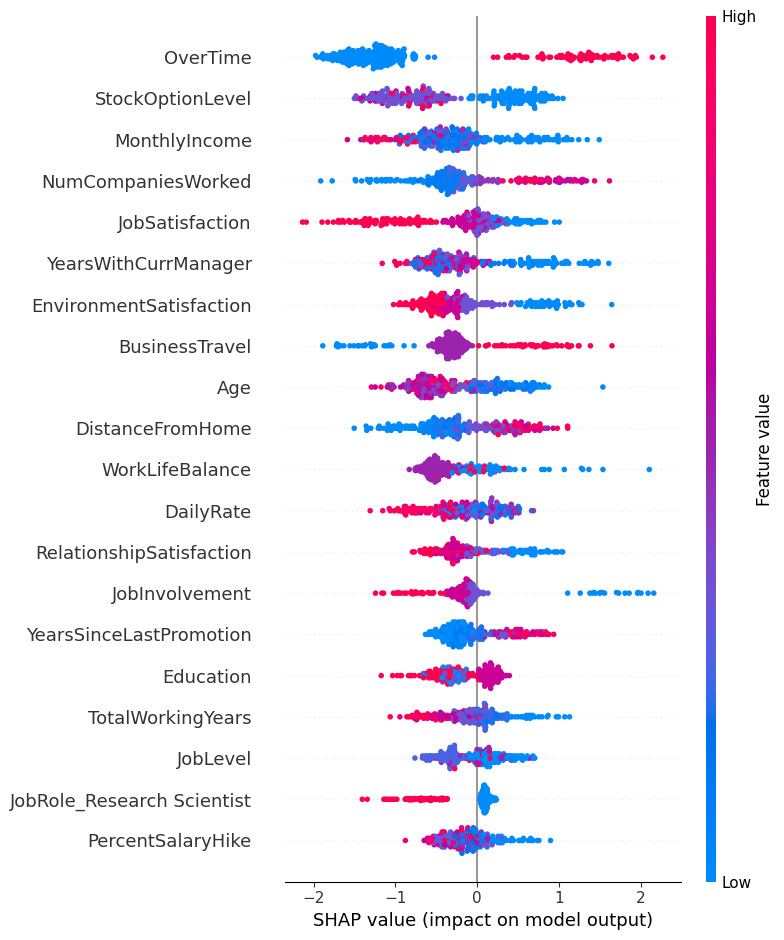

In [10]:
shap.summary_plot(shap_values, X_test, feature_names = feature_names)

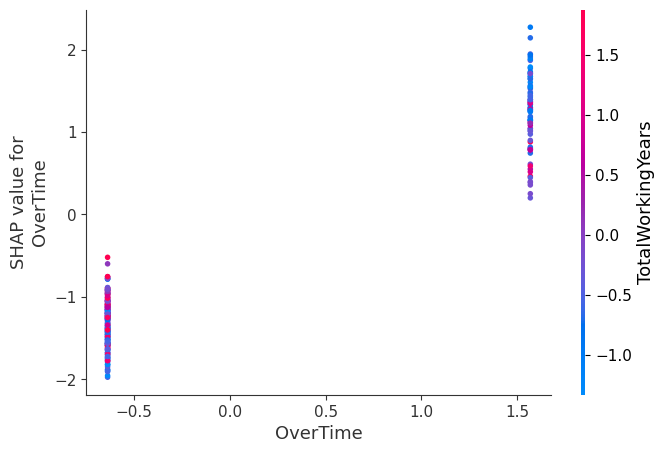

In [11]:
shap.dependence_plot('OverTime', shap_values, X_test, feature_names = feature_names)

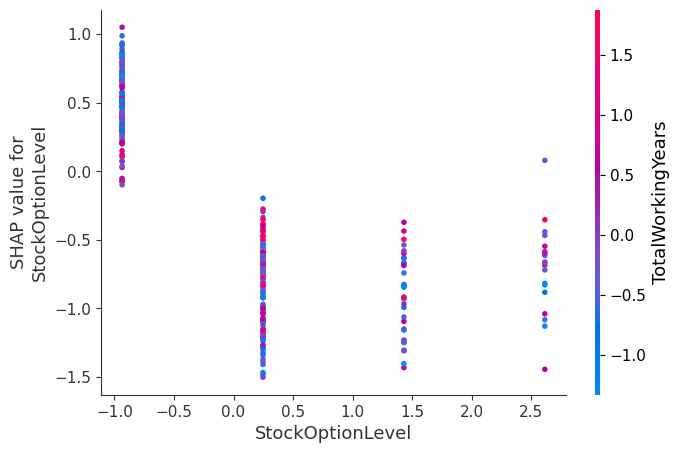

In [12]:
shap.dependence_plot('StockOptionLevel', shap_values, X_test, feature_names = feature_names)

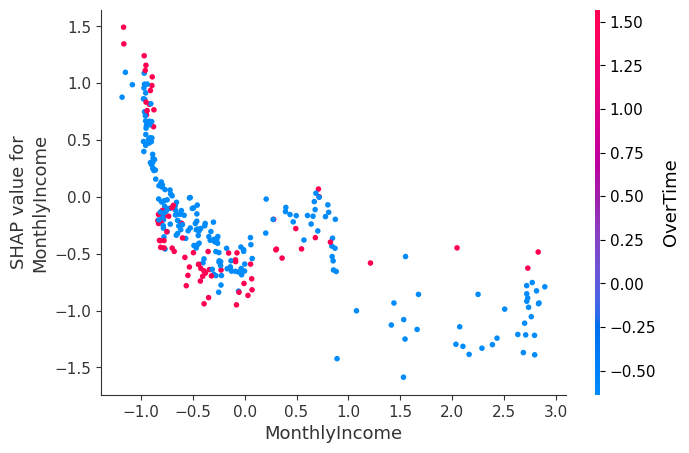

In [13]:
shap.dependence_plot('MonthlyIncome', shap_values, X_test, feature_names = feature_names)

In [14]:
probs = model.predict_proba(X_test)[:,1]

In [15]:
high_risk_idx = probs.argmax()
print("Highest risk index:", high_risk_idx, "Probability:", probs[high_risk_idx])

Highest risk index: 92 Probability: 0.9996363


In [16]:
low_risk_idx = probs.argmin()
print("Lowest risk index:", low_risk_idx, "Probability:", probs[low_risk_idx])

Lowest risk index: 260 Probability: 1.4220545e-05


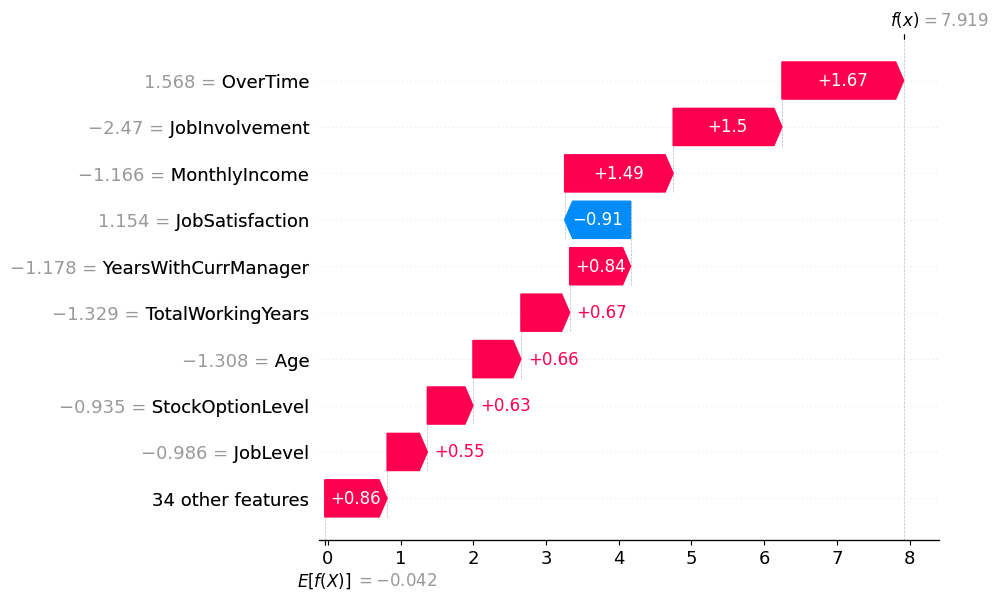

In [17]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=feature_names
))

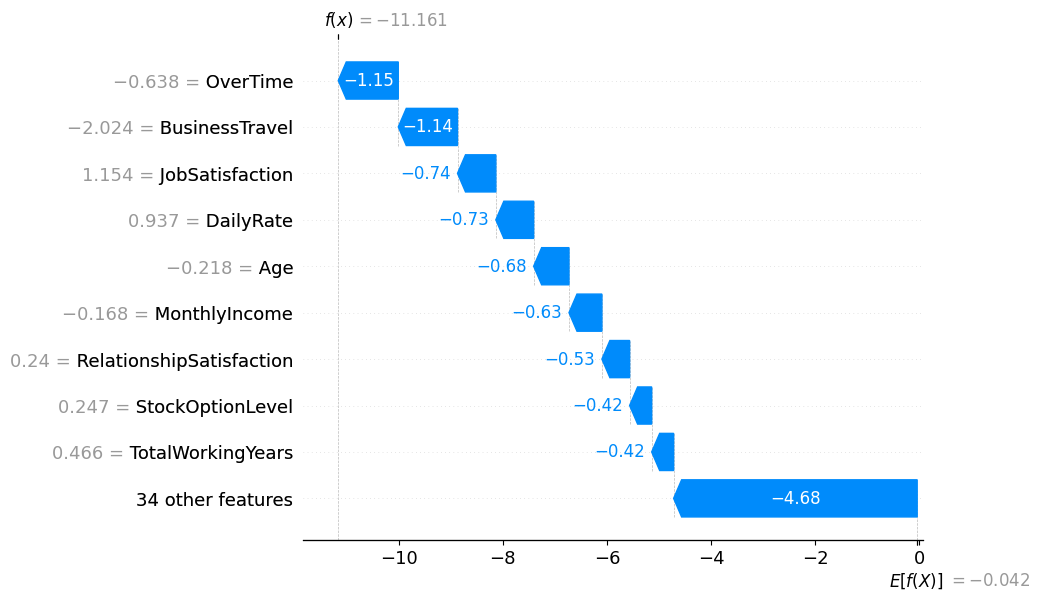

In [18]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[low_risk_idx],
    feature_names=feature_names
))